# Numerical Solution of Second-Order ODEs 
###        UT Austin white/albino squirrel campus population
Morgan Gaitz mmg4947 

 ## Introduction & Model Selection
 
- Brief description of your chosen real-world system
- The governing second-order ODE
- Conversion to a system of first-order ODEs
- Physical meaning of each variable and parameter


For this project, I am modeling the UT Austin white/albino squirrel population on campus. The “albino squirrel” is part of a campus tradition where seeing one before a test is considered good luck, but UT explains that these squirrels are not technically true albino squirrels dispite popular belif.They are actully better described as white fox squirrels or a white color variant because true albino squirrels would have red eyes, while the campus squirrels have brown eyes. This makes the population interesting to model because it is a small and rare subpopulation, not the entire squirrel population on campus.

I chose a modified logistic population growth model because campus has limiting factors to concider. A population cannot realistically grow forever because food, shelter, space, mates, and habitat all limit the number of squirrels an area can support. Logistic growth is perfect when population growth slows as the population approaches a carrying capacity (K). In my model, P(t) represents the population of white squirrels, and v(t) represents the growth rate of that population.

This model is based on the idea that the growth rate does not instantly adjust. Instead, the population has a delay or adjustment time because of things like reproduction and survival happen over months or years. This gives the system the form dP/dt=v and dv/dt= a(rP(1−P/K)−v). The parameter r controls the natural growth rate, K is the carrying capacity, and a controls how quickly the growth rate adjusts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def squirrel_model(t, y, r, K, a):
    
    P = y[0] #population of white/albino squirrels at any guven year
    v = y[1] #growth rate of the population at any given year

    logistic_target = r * P * (1 - P / K)
    dP_dt = v
    dv_dt = a * (logistic_target - v)

    return np.array([dP_dt, dv_dt])

## Parameter Research & Justification

- Table of all parameters with values, units, and sources
- Initial conditions with justification
- Description of the physical scenario being modeled


In [2]:
# temporary test values so the code runs until i can research
P0 = 3.0
K = 12.0
r = 2.0
a = 0.5
v0 = 0.0

y0 = np.array([P0, v0])


The exact number of white fox squirrels on UT’s campus is not researched or published, so the values in this model are estimates based on the biological facts and specific cercumstancises being modeled. I chose a small initial population because UT describes the white squirrels as only “a few” white fox squirrels. I also chose a small carrying capacity because this model is only for the white color variant subpopulation, not all fox squirrels living near campus. Since the white color variant is rare, the carrying capacity should remain much smaller than the total number of normal colored squirrels.

The growth rate parameter is also an estimate because it represents effective population growth, not just the number of squirrels born. Fox squirrels usually have two breeding seasons per year, and the births are usually 3–4 per litter. However, not every squirrel will survive, remain on campus, or have the white color variation, so the effective growth rate should be lower than the raw birth rate. The adjustment parameter a represents the delay in how quickly the population growth rate reacts. This is reasonable because fox squirrels reach maturity around 10 to 11 months, meaning population changes do not happen instantly.

## Numerical Methods Implementation

- Well-commented Python functions for:
    - Euler's Forward method
    - RK4 method
- Brief explanation of your implementation approach


In [3]:
# Eulers Foward
def Euler(y_not, step, start, stop, r, K, alpha):
    
    num_steps = int(round((stop - start) / step))
    t = np.linspace(start, stop, num_steps + 1)

    #make array to store population and growth rate
    y = np.zeros((num_steps + 1, len(y_not)))

    #initial condition
    y[0] = y_not

    #go through each step
    for i in range(num_steps):
        slope = squirrel_model(t[i], y[i], r, K, alpha)
        y[i + 1] = y[i] + step * slope

    return t, y

def RK4(y_not, step, start, stop, r, K, alpha):
    
    num_steps = int(round((stop - start) / step))
    t = np.linspace(start, stop, num_steps + 1)

    #make array to store population and growth rate
    y = np.zeros((num_steps + 1, len(y_not)))

    #initial condition
    y[0] = y_not

    # go through each step
    for i in range(num_steps):
        k1 = squirrel_model(t[i], y[i], r, K, alpha)
        k2 = squirrel_model(t[i] + step / 2, y[i] + (step / 2) * k1, r, K, alpha)
        k3 = squirrel_model(t[i] + step / 2, y[i] + (step / 2) * k2, r, K, alpha)
        k4 = squirrel_model(t[i] + step, y[i] + step * k3, r, K, alpha)

        y[i + 1] = y[i] + (step / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return t, y

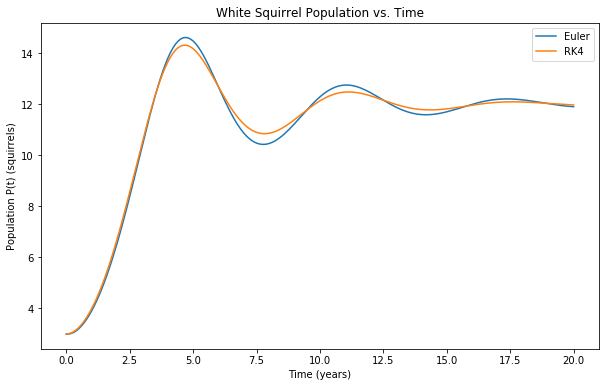

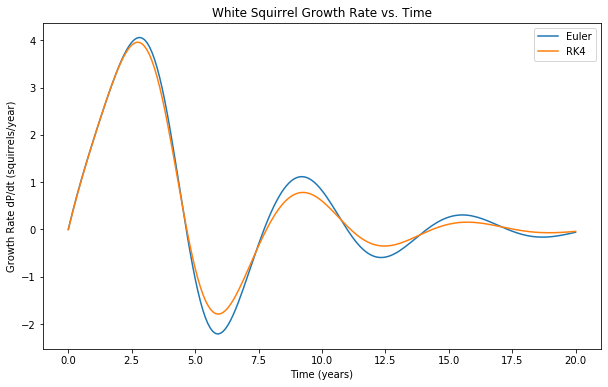

In [4]:
# implement the methods
start = 0
stop = 20
step = 0.1

t_euler, y_euler = Euler(y0, step, start, stop, r, K, a)
t_rk4, y_rk4 = RK4(y0, step, start, stop, r, K, a)



# plotting results

#population
plt.figure(figsize=(10, 6))

plt.plot(t_euler, y_euler[:,0], label="Euler")
plt.plot(t_rk4, y_rk4[:, 0], label="RK4")

plt.xlabel("Time (years)")
plt.ylabel("Population P(t) (squirrels)")
plt.title("White Squirrel Population vs. Time")
plt.legend()
plt.show()

# growth rate
plt.figure(figsize=(10, 6))

plt.plot(t_euler, y_euler[:, 1], label="Euler")
plt.plot(t_rk4, y_rk4[:, 1], label="RK4")

plt.xlabel("Time (years)")
plt.ylabel("Growth Rate dP/dt (squirrels/year)")
plt.title("White Squirrel Growth Rate vs. Time")
plt.legend()
plt.show()


To solve the second-order model, I first converted it into a system of two first-order equations. This is necessary because Euler’s Forward method and RK4 are easier to apply in this format. In my code, y[0] stores the population P(t), and y[1] stores the growth rate v(t). This means the full y array stores both values at each time step.

Euler’s Forward method updates the solution using the slope at the beginning of each time interval. This makes Euler’s method simple and easy to understand, but it can become inaccurate if the step size is too large becuase error building on its self fast. RK4 uses four slope estimates during each step, so the more terms found should give a more accurate solution. I use the same initial conditions and parameter values on both so I can compare their accuracy, stability, and behavior.

## Solutions & Comparison

- Results from both methods with multiple step sizes
- Comparison plots (position vs. time, velocity vs. time)
- Phase portraits (if applicable)
- Discussion of visual differences between methods


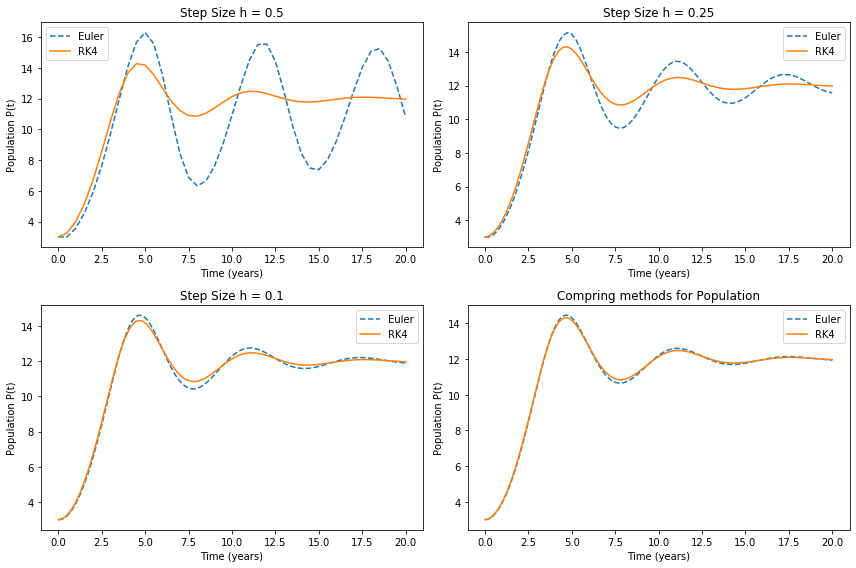

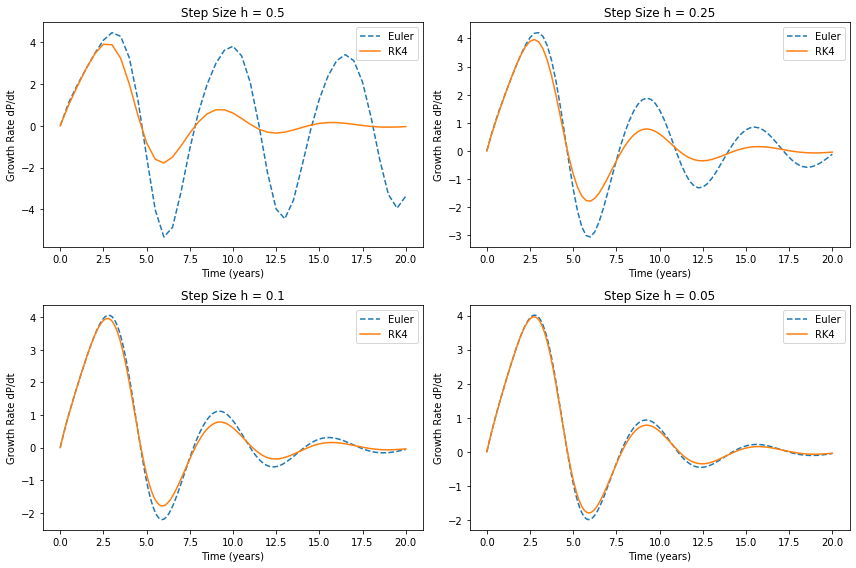

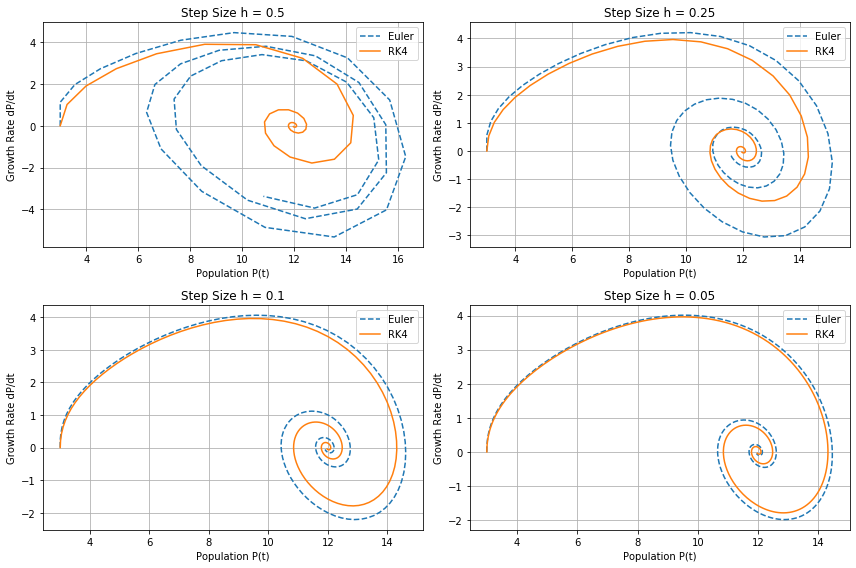

In [5]:
# code for comparing the two methods

step_sizes = [0.5, 0.25, 0.1, 0.05]
solutions = {} #store to gragh later
for h in step_sizes:
    t_euler, y_euler = Euler(y0, h, start, stop, r, K, a)
    t_rk4, y_rk4 = RK4(y0, h, start, stop, r, K, a)
    
    solutions[("Euler", h)] = (t_euler, y_euler)
    solutions[("RK4", h)] = (t_rk4, y_rk4)

    
    
#graghing results

# make subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# flatten axes so it is easier to loop through
axes = axes.flatten()

# go through each step size
for i in range(len(step_sizes)):
    h = step_sizes[i]

    # get Euler and RK4 values for this step size
    t_euler, y_euler = solutions[("Euler", h)]
    t_rk4, y_rk4 = solutions[("RK4", h)]

    # choose which subplot to use
    ax = axes[i]

    # plot population for both methods
    ax.plot(t_euler, y_euler[:, 0], linestyle="--", label="Euler")
    ax.plot(t_rk4, y_rk4[:, 0], label="RK4")

    # labels and title for each subplot
    ax.set_title(f"Step Size h = {h}")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Population P(t)")
    ax.legend()

# make layout look cleaner

plt.tight_layout()
plt.title("Compring methods for Population")
plt.show()




# growth rate comparison for each step size

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(len(step_sizes)):
    h = step_sizes[i]

    t_euler, y_euler = solutions[("Euler", h)]
    t_rk4, y_rk4 = solutions[("RK4", h)]

    ax = axes[i]

    ax.plot(t_euler, y_euler[:, 1], linestyle="--", label="Euler")
    ax.plot(t_rk4, y_rk4[:, 1], label="RK4")

    ax.set_title(f"Step Size h = {h}")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Growth Rate dP/dt")
    ax.legend()

plt.tight_layout()
plt.show()


#phase portrait comparison for each step size

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(len(step_sizes)):
    h = step_sizes[i]

    t_euler, y_euler = solutions[("Euler", h)]
    t_rk4, y_rk4 = solutions[("RK4", h)]

    ax = axes[i]

    ax.plot(y_euler[:, 0], y_euler[:, 1], linestyle="--", label="Euler")
    ax.plot(y_rk4[:, 0], y_rk4[:, 1], label="RK4")

    ax.set_title(f"Step Size h = {h}")
    ax.set_xlabel("Population P(t)")
    ax.set_ylabel("Growth Rate dP/dt")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

The population plots show how the predicted white squirrel population changes over time for different step sizes. For smaller step sizes, Euler and RK4 are closer together because both methods are taking more smaller step sizes and getting more updates. For larger step sizes, Euler to drifts away from RK4 because it only uses the slope at the beginning of each interval and simpler then the RK4 method. RK4 is expected to be smoother because it averages information from multiple points and slopes during each step.

The population should generally move toward the carrying capacity K, which is the max number of white squirrels the campus environment can support. When the population starts below K, the growth rate begins positive because there is still room for the population to increase. As the population gets closer to K, the growth rate decreases. This goes along with the idea that population growth slows when resources are more limited.

The phase portrait compares population P(t) with growth rate dP/dt. This helps show how the system behaves beyond just population versus time. If the model is behaving realistically, the growth rate should eventually move toward zero as the population approaches carrying capacity. This means the population is no longer changing quickly and the system is approaching an equilibrium.

## Stability Analysis

- Demonstration of stability limits for each method
- Error analysis with appropriate plots
- Discussion of stable vs. unstable behavior
- Physical interpretation of results


,method,step size,mean population error,max population error,final population error
0,Euler,0.50,1.986277e+00,4.540839e+00,1.154594e+00
1,RK4,0.50,1.316228e-03,4.569124e-03,1.344810e-04
2,Euler,0.25,5.161472e-01,1.388224e+00,4.047826e-01
3,RK4,0.25,8.017113e-05,2.700796e-04,8.755881e-07
4,Euler,0.10,1.493255e-01,4.248828e-01,6.760098e-02
5,RK4,0.10,2.013908e-06,6.534920e-06,8.361184e-08
6,Euler,0.05,6.824751e-02,1.956520e-01,2.581025e-02
7,RK4,0.05,1.250466e-07,4.000177e-07,7.330142e-09


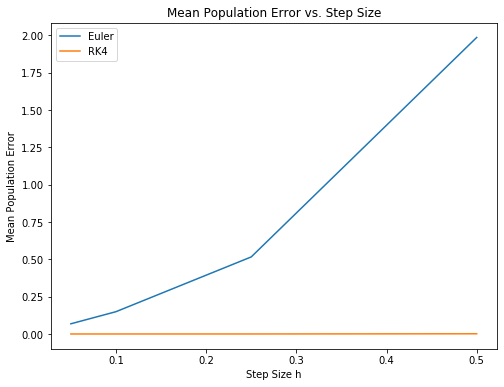

In [6]:
# code for doing the stability analysis for each method
h_sol = 0.001 # aince no exact solution, compaing using a very small step size of the more accurate method. 
t_sol, y_sol = RK4(y0, h_sol, start, stop, r, K, a)

def sol(t_ref, y_ref, t_values):
    P_sol = np.interp(t_values, t_sol, y_sol[:, 0])
    v_sol = np.interp(t_values, t_sol, y_sol[:, 1])

    return np.column_stack((P_sol, v_sol))




import pandas as pd
from IPython.display import display

error_results = []

for h in step_sizes:
    t_euler, y_euler = solutions[("Euler", h)]
    t_rk4, y_rk4 = solutions[("RK4", h)]

    y_sol_euler = sol(t_sol, y_sol, t_euler)
    y_sol_rk4 = sol(t_sol, y_sol, t_rk4)

    euler_error = abs(y_euler[:, 0] - y_sol_euler[:, 0])
    rk4_error = abs(y_rk4[:, 0] - y_sol_rk4[:, 0])

    error_results.append({
        "method": "Euler",
        "step size": h,
        "mean population error": np.mean(euler_error),
        "max population error": np.max(euler_error),
        "final population error": euler_error[-1]
    })

    error_results.append({
        "method": "RK4",
        "step size": h,
        "mean population error": np.mean(rk4_error),
        "max population error": np.max(rk4_error),
        "final population error": rk4_error[-1]
    })

error_table = pd.DataFrame(error_results)
display(error_table)


plt.figure(figsize=(8, 6))

# get the Euler rows
euler_data = error_table[error_table["method"] == "Euler"]

# get the RK4 rows
rk4_data = error_table[error_table["method"] == "RK4"]

# plot Euler error
plt.plot(euler_data["step size"], euler_data["mean population error"], label="Euler")

# plot RK4 error
plt.plot(rk4_data["step size"], rk4_data["mean population error"], label="RK4")

plt.xlabel("Step Size h")
plt.ylabel("Mean Population Error")
plt.title("Mean Population Error vs. Step Size")
plt.legend()
plt.show()

Stable behavior means the numerical method simulates a realistic population over time. Since this is a squirrel population model, unrealistic behavior would be getting negative population values, sudden wild growth, or extreme oscillations that are natural in the enviorment. Stability is important because even if the equation makes sense, a bad step size choice can make the solution produced unreliable and not accurate.

The error analysis compares Euler and RK4 to a reference solution made using RK4 (the more accurate method) with a very small step size. This solution is a reasonable comparison althogh not completly exact. Euler usually has a larger error than RK4 for the same step size because Euler only uses one slope estimate per step. RK4 has smaller error because it uses more temrs from the taylor expantion series to better approximate the curve.

As the step size decreases, both methods become more accurate. However, RK4 gets more accurate faster than Euler. The gragh shows that Euler has a much larger error for larger step sizes becuase it is sensitive to changes in step size. RK4 stays close to the reference solution even for larger step sizes. RK4 is the better method for this model when accuracy is the priority.

## Conclusions 

- Which method performed better for your problem?
- Computational cost vs. accuracy tradeoff
- Practical recommendations
- Lessons learned


Overall, RK4 performed better for this population growth model because it gave smoother and more accurate results for the same step sizes. Euler’s Forward method was easier to implement and understand, but it became less reliable when the step size was larger. When the step size is smaller it takes more computing power to simulate becuase it has to calculate more times. This shows the tradeoff between simplicity and accuracy.

The main computational cost trade off is that Euler only evaluates the model once per step using one term, while RK4 evaluates it four times per step expanding the calcuation to 4 terms. This means RK4 takes more work per step, but it can get away with using a larger step size while still staying accurate. RK4 in this case is the better method because the squirrel population is small so long term behavior matters more than saving a small amount of time.

The biggest take away from this project is that choosing a realistic model and researching parameters is just as important as writing the actual method correctly. The research and the justification for the values chosen took more time than applying the methods and helped explain why the results were behahving ina particlar way. Additionally, the stability analysis was what visually showed how error builds up with differnt methods. This tool is something to keep in mind for feature simulations to determine what method makes the most sense to apply when diffent 

# Sources

Clark, M. A., Douglas, M., & Choi, J. (2018, March 28). 45.3 Environmental limits to population growth. In Biology 2e. OpenStax. https://openstax.org/books/biology-2e/pages/45-3-environmental-limits-to-population-growth

Academic Programs for Undergraduates. (n.d.). The legend of the albino squirrel. The University of Texas at Austin. https://undergraduates.utexas.edu/legend-albino-squirrel

Texas Parks and Wildlife Department. (n.d.). Eastern fox squirrel (Sciurus niger). https://tpwd.texas.gov/huntwild/wild/species/easternfoxsquirrel/

The pandas development team. (n.d.). Table visualization. In pandas 3.0.2 documentation. https://pandas.pydata.org/docs/user_guide/style.html


# AI citations
##### chatGPT was used for every prompt



What is the best way to represent the second order ODE for population growth to be solved using numerical methods in Python? (attached instruction file)
- Why: Google the instructions did not agree on what the second order ODE should be so i need

What is wrong with my RK4 and Eulers forward method implementation (attached current code)
- Why: the graphs I was getting back didn't seem to make sense and i didnt know where my error was. 

I want to compare method results to each other at different step sizes, how do I make the subplots look clean and readable? I want one subplot for each step size, with Euler and RK4 compared inside each subplot. (attached the current code)
- Why: There were a lot of graphs I wanted to display in a clean way but didn't know what the code needed to be to keep it readable and simple for outsiders to look at. I ended up reusing this code for other subplots and changing variables to display other graphs as well

What do phase portraits tell you and is this the proper way to implement it? (attached current code and phase portrait output)
- Why: I was using a phase portrait to represent the data in a diff way but i had never used one or knew what it meant.

What is the best way to analyze the stability and accuracy of the solutions and keep it readable? Make a table to represent the error resulting at different step sizes for the two methods comparing it to the solution. (attached current code)
- Why: There were a lot of numbers I calculated but I had never made a table in python to cleanly display them.

Am I missing anything to receive full credit on this project? How can the written analysis paragraphs be improved to flow better? Do the comments left on the code make it clear what is happening in the code to produce the output? (attached current code and instruction file)
- Why: doing final touches and wanted to make sure I wasn't missing anything important. 

Put these into APA format (attached all links)
- Why: needed help formatting the sources i found 
